In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as python_random
import tensorflow as tf 
from sklearn .metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K
from tensorflow.keras.applications import vgg16
from tensorflow.keras.layers import Dense, Flatten, Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam




I0000 00:00:1782651255.314990    1297 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782651255.386642    1297 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782651256.858199    1297 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [9]:
dataset_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset"

print("Folders in dataset:")
print(os.listdir(dataset_path))

Folders in dataset:
['Covid19-dataset']


In [10]:
train_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/train"
test_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/test"

print("Train classes:")
print(os.listdir(train_path))

print("\nTest classes:")
print(os.listdir(test_path))

Train classes:
['Viral Pneumonia', 'Covid', 'Normal']

Test classes:
['Viral Pneumonia', 'Covid', 'Normal']


In [11]:
np.random.seed(42)
tf.random.set_seed(42)


In [12]:
base_model = vgg16.VGG16(weights='imagenet')
print(base_model.summary())

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
Height=224
Width=224
Batch_size=32

In [14]:
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [15]:
#For augmentation, you can use the following code:
# train_gen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True)

In [21]:
train_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/train"
test_path = "/home/mariam/Projects/covid-Xray-finetuning/data/COVID-19_Radiography_Dataset/Covid19-dataset/test"
#Normalizing the images and creating the training and testing datasets
train_data = train_gen.flow_from_directory (
    train_path,
    target_size=(Height, Width),
    batch_size=Batch_size,
    class_mode='sparse',
    shuffle=True,
   )
test_data = test_gen.flow_from_directory (
    test_path,
    target_size=(Height, Width),
    batch_size=Batch_size,
    class_mode='sparse',
    shuffle=False,
   )

 

Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [22]:
print(train_data.class_indices)

{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [26]:
total_image=np.concatenate([train_data.labels, test_data.labels])

In [27]:
print("Normal images:", np.sum(total_image == 0))
print("Covid images:", np.sum(total_image == 1))
print("Viral Pneumonia images:", np.sum(total_image == 2))

Normal images: 137
Covid images: 90
Viral Pneumonia images: 90


In [30]:
train_data.labels.shape

(251,)

In [40]:
print(train_data.labels[:500])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [41]:
np.unique(train_data.labels)

array([0, 1, 2], dtype=int32)

In [ ]:
#Display images
image, label = next(train_data)




In [44]:
#per Batch
label.shape

(32,)

In [65]:
def plot_images(image_arr, label_arr, class_indices):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8))
    axes = axes.flatten()

    for img, lbl, ax in zip(image_arr, label_arr, axes):
        ax.imshow(img)

        label = list(class_indices.keys())[
            list(class_indices.values()).index(int(lbl))
        ]

        ax.set_title(label)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    

In [58]:
label[:5]

array([1., 0., 1., 0., 1.], dtype=float32)

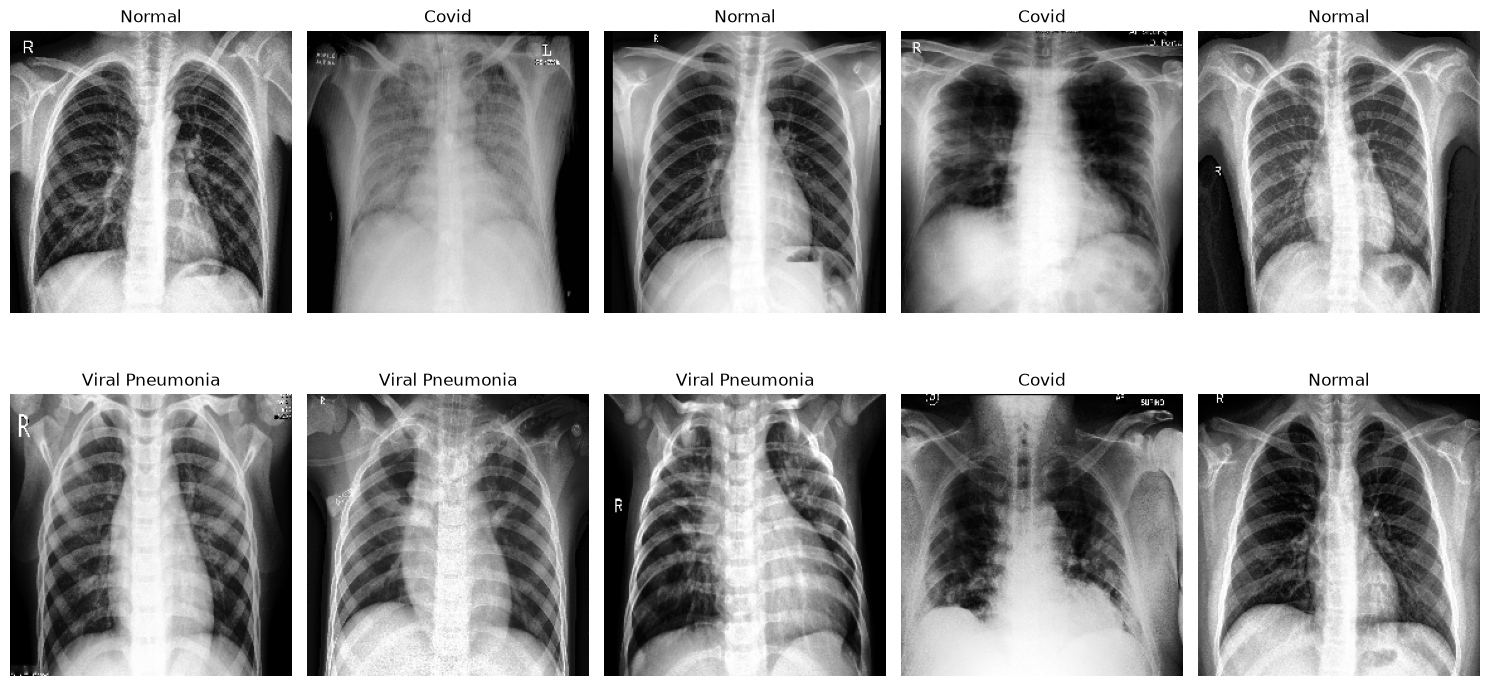

In [66]:
plot_images(image[:15], label[:15], train_data.class_indices)